# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

Install Required Libraries

In [3]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2
%pip install pandas
%pip install pyspark==3.5.4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date

spark = SparkSession.builder \
    .appName("Traffic Collision Analysis") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [5]:
# Write code to load the data and check the schema
# Load all CSV files

collisions = spark.read.csv("sample_collisions.csv", header=True, inferSchema=True)
parties = spark.read.csv("sample_parties.csv", header=True, inferSchema=True)
victims = spark.read.csv("sample_victims.csv", header=True, inferSchema=True)
case_ids = spark.read.csv("sample_case_ids.csv", header=True, inferSchema=True)

# Check Schema
print("Collisions Schema")
collisions.printSchema()

print("Parties Schema")
parties.printSchema()

print("Victims Schema")
victims.printSchema()

print("Case IDs Schema")
case_ids.printSchema()


Collisions Schema
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: double (nulla

#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [6]:
#Display Schema & Sample Data

print("===== Collisions =====")
collisions.printSchema()
collisions.show(5, truncate=False)

print("===== Parties =====")
parties.printSchema()
parties.show(5, truncate=False)

print("===== Victims =====")
victims.printSchema()
victims.show(5, truncate=False)

print("===== Case IDs =====")
case_ids.printSchema()
case_ids.show(5, truncate=False)


===== Collisions =====
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: double (

##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [7]:
#Check for Missing Values

from pyspark.sql.functions import col, when, count

print("===== Collisions Missing Values =====")
collisions.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in collisions.columns
]).show()

print("===== Parties Missing Values =====")
parties.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in parties.columns
]).show()

print("===== Victims Missing Values =====")
victims.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in victims.columns
]).show()

print("===== Case IDs Missing Values =====")
case_ids.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in case_ids.columns
]).show()

===== Collisions Missing Values =====
+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+--------------------

In [8]:
#Drop Sparse Columns
# No sparse columns removed at this stage
print("No sparse columns removed.")

No sparse columns removed.


In [9]:
#Convert Data Types

from pyspark.sql.functions import col, to_date

collisions = collisions.withColumn(
    "collision_date",
    to_date(col("collision_date"), "yyyy-MM-dd")
)

print("Data types converted successfully.")

Data types converted successfully.


In [10]:
#Handle Missing Values

from pyspark.sql.functions import when

collisions = collisions.fillna("Unknown")
parties = parties.fillna("Unknown")
victims = victims.fillna("Unknown")
case_ids = case_ids.fillna(0)

print("Missing values handled.")

Missing values handled.


##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [11]:
#Remove Duplicates

collisions = collisions.dropDuplicates()
parties = parties.dropDuplicates()
victims = victims.dropDuplicates()
case_ids = case_ids.dropDuplicates()

print("Duplicates removed.")


Duplicates removed.


In [12]:
#Detect Outliers using IQR

# List of numerical columns to check for outliers

numerical_cols = [
    "killed_victims",
    "injured_victims"
]

for column in numerical_cols:
    if column in collisions.columns:

        q1, q3 = collisions.approxQuantile(column, [0.25, 0.75], 0.01)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = collisions.filter(
            (col(column) < lower) | (col(column) > upper)
        )

        print(f"{column} Outliers:", outliers.count())


killed_victims Outliers: 0
injured_victims Outliers: 33313


##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [13]:
#Remove Outliers

# Remove Outliers

q1, q3 = collisions.approxQuantile("injured_victims", [0.25, 0.75], 0.01)

iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

collisions = collisions.filter(
    (col("injured_victims") >= lower) &
    (col("injured_victims") <= upper)
)

print("Outliers removed successfully.")
print("Remaining rows:", collisions.count())

Outliers removed successfully.
Remaining rows: 902248


#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [14]:
# Encode Categorical Variables

# String Indexing for Categorical Columns

from pyspark.ml.feature import StringIndexer

categorical_cols = ["weather_1", "lighting", "road_condition_1"]

for col_name in categorical_cols:
    if col_name in collisions.columns:
        indexer = StringIndexer(
            inputCol=col_name,
            outputCol=col_name + "_index",
            handleInvalid="keep"
        )
        collisions = indexer.fit(collisions).transform(collisions)

print("Categorical encoding completed.")

Categorical encoding completed.


In [15]:
# Reordering & Renaming Columns

collisions = collisions.select(sorted(collisions.columns))

print("columns reordered successfully.")
print(collisions.columns)


columns reordered successfully.
['beat_number', 'beat_type', 'bicycle_collision', 'bicyclist_injured_count', 'bicyclist_killed_count', 'caltrans_county', 'caltrans_district', 'case_id', 'chp_beat_class', 'chp_beat_type', 'chp_road_type', 'chp_shift', 'chp_vehicle_type_at_fault', 'collision_date', 'collision_severity', 'collision_time', 'complaint_of_pain_injury_count', 'control_device', 'county_city_location', 'county_location', 'direction', 'distance', 'hit_and_run', 'injured_victims', 'intersection', 'jurisdiction', 'killed_victims', 'latitude', 'lighting', 'lighting_index', 'location_type', 'longitude', 'motor_vehicle_involved_with', 'motorcycle_collision', 'motorcyclist_injured_count', 'motorcyclist_killed_count', 'not_private_property', 'officer_id', 'other_visible_injury_count', 'party_count', 'pcf_violation', 'pcf_violation_category', 'pcf_violation_subsection', 'pedestrian_action', 'pedestrian_collision', 'pedestrian_injured_count', 'pedestrian_killed_count', 'population', 'pos

In [16]:
# Final cleaned data

collisions.show(5, truncate=False)

print("Total Rows:", collisions.count())
print("Total columns:", len(collisions.columns))

+-----------+-----------------+-----------------+-----------------------+----------------------+---------------+-----------------+---------+--------------+-------------+-------------+--------------+-------------------------+--------------+--------------------+-------------------+------------------------------+--------------+--------------------+---------------+---------+--------+---------------+---------------+------------+------------+--------------+--------+--------------------------+--------------+-------------+----------+---------------------------+--------------------+--------------------------+-------------------------+--------------------+----------+--------------------------+-----------+-------------+----------------------+------------------------+----------------------+--------------------+------------------------+-----------------------+----------------+--------+------------------------+------------+------------+------------------+----------------+----------------------+-----

Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

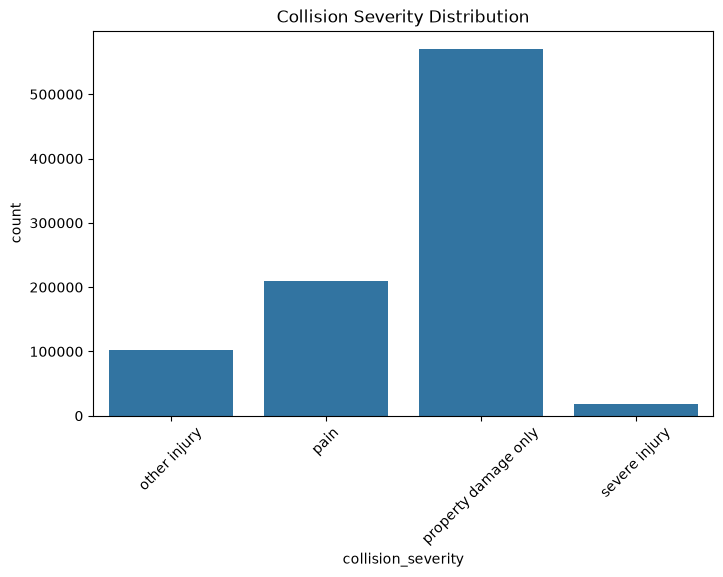

In [17]:
# Univariate Analysis

# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

severity_df = (
    collisions.groupBy("collision_severity")
    .count()
    .orderBy("collision_severity")
)

severity_pd = severity_df.toPandas()

plt.figure(figsize=(8,5))

sns.barplot(
    data=severity_pd,
    x="collision_severity",
    y="count"
)

plt.title("Collision Severity Distribution")
plt.xticks(rotation=45)
plt.show()

# Convert to Pandas

# Plot


##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

+---------+------+
|weather_1| count|
+---------+------+
|    clear|741919|
|   cloudy|117995|
|  raining| 31339|
|  Unknown|  4457|
|      fog|  3779|
|  snowing|  1326|
|    other|  1057|
|     wind|   376|
+---------+------+



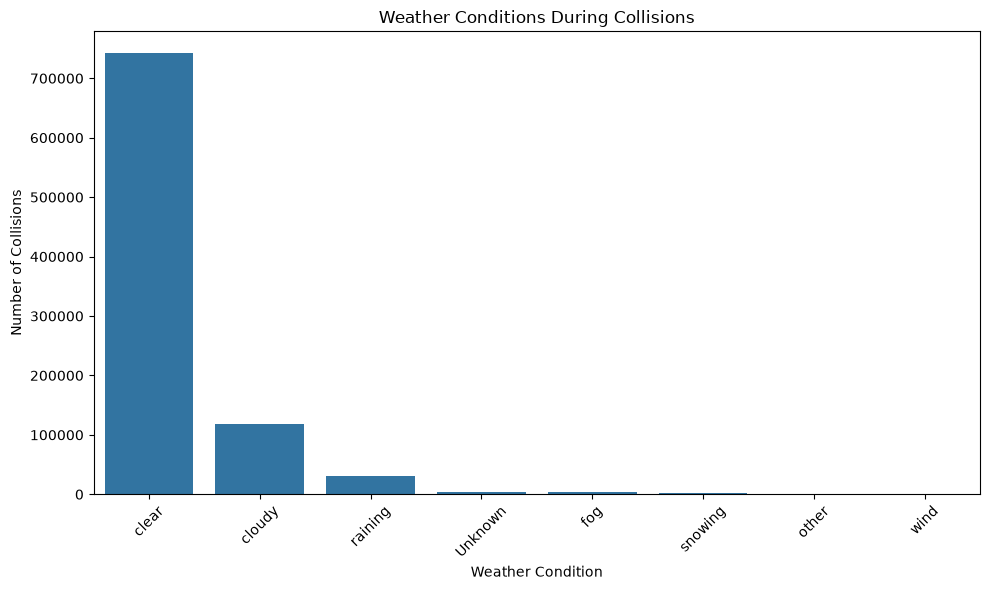

In [18]:
# Weather Conditions During Collisions

weather_df = (
    collisions
    .groupBy("weather_1")
    .count()
    .orderBy("count", ascending=False)
)

# Display summary table
weather_df.show()

# Convert to Pandas for visualization
weather_pd = weather_df.toPandas()

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weather_pd,
    x="weather_1",
    y="count"
)

plt.title("Weather Conditions During Collisions")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

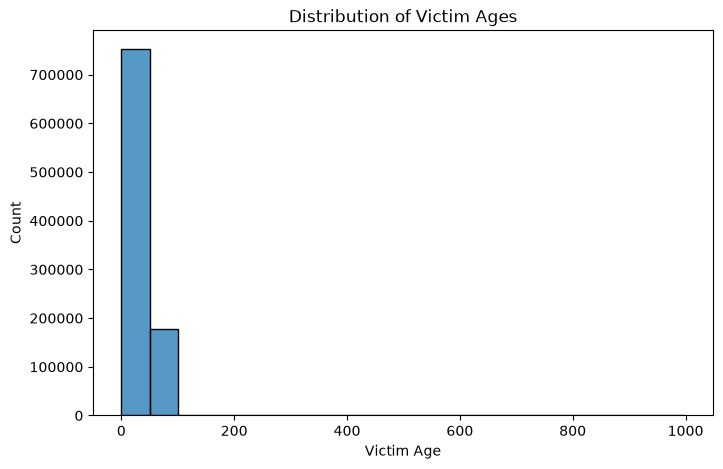

In [19]:
# Distribution of Victim Ages

# Convert to Pandas
# Distribution of Victim Ages

# Convert to Pandas
victim_age_pd = victims.select("victim_age").toPandas()

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    data=victim_age_pd,
    x="victim_age",
    bins=20
)

plt.title("Distribution of Victim Ages")
plt.xlabel("Victim Age")
plt.ylabel("Count")
plt.show()

# Plot


##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

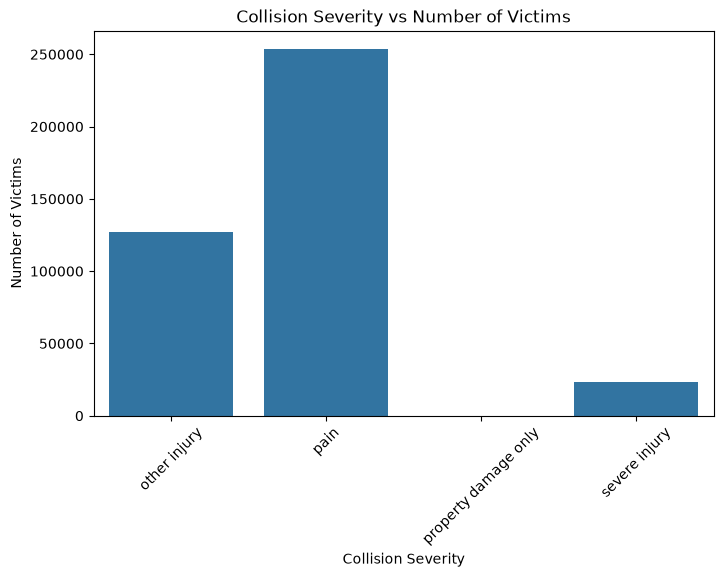

In [20]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims

# Convert to Pandas
victims_count_df = (
    collisions
    .groupBy("collision_severity")
    .sum("injured_victims", "killed_victims")
    .orderBy("collision_severity")
)

victims_count_pd = victims_count_df.toPandas()

# Calculate total victims
victims_count_pd["total_victims"] = (
    victims_count_pd["sum(injured_victims)"] +
    victims_count_pd["sum(killed_victims)"]
)

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=victims_count_pd,
    x="collision_severity",
    y="total_victims"
)

plt.title("Collision Severity vs Number of Victims")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Victims")
plt.xticks(rotation=45)
plt.show()



##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

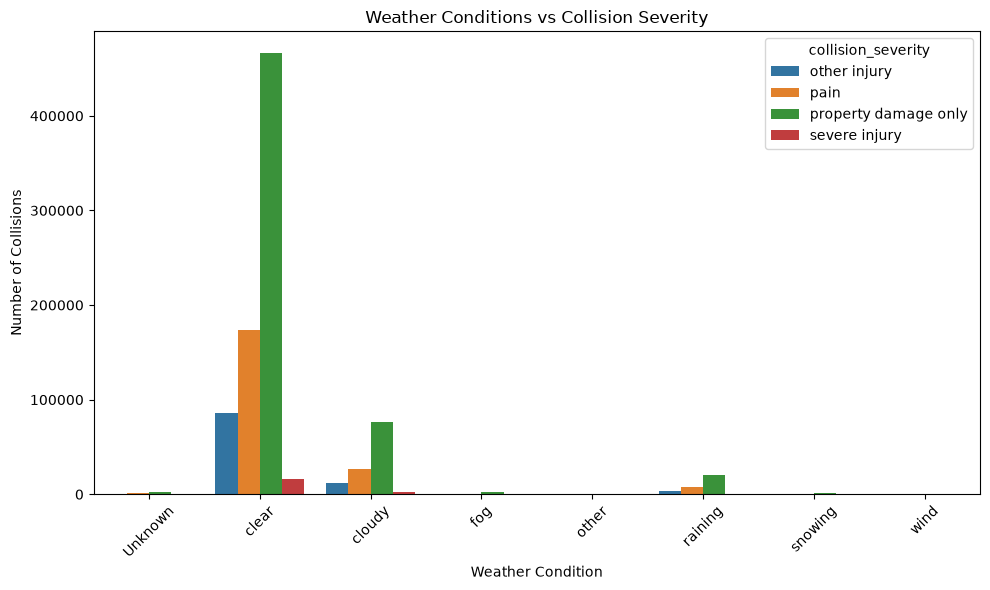

In [21]:
# Weather vs. Collision Severity

# Convert to Pandas

weather_severity_df = (
    collisions
    .groupBy("weather_1", "collision_severity")
    .count()
    .orderBy("weather_1", "collision_severity")
)

weather_severity_pd = weather_severity_df.toPandas()

# Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weather_severity_pd,
    x="weather_1",
    y="count",
    hue="collision_severity"
)

plt.title("Weather Conditions vs Collision Severity")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

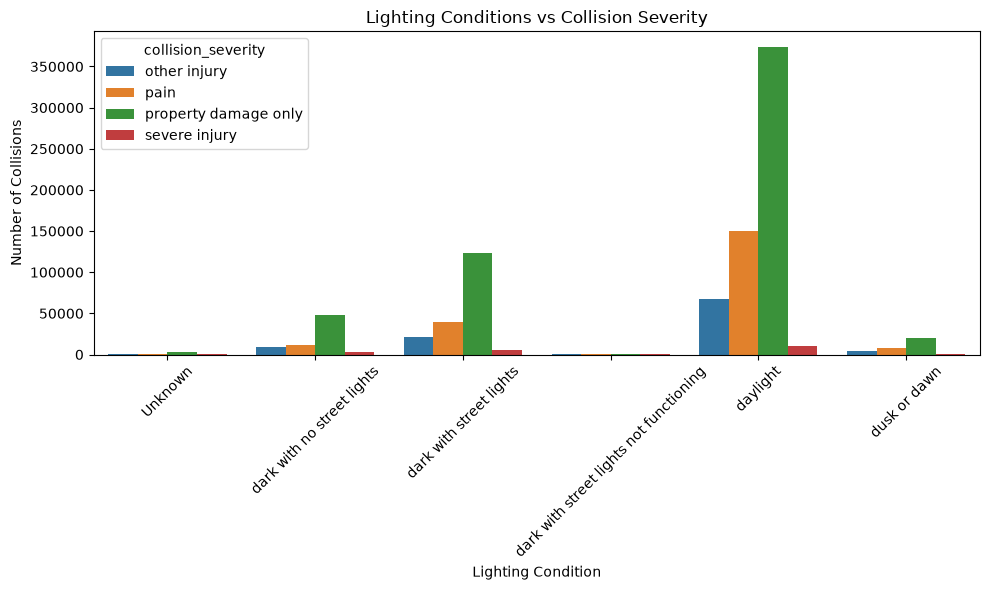

In [22]:
# Lighting Conditions vs. Collision Severity

# Convert to Pandas

lighting_severity_df = (
    collisions
    .groupBy("lighting", "collision_severity")
    .count()
    .orderBy("lighting", "collision_severity")
)

lighting_severity_pd = lighting_severity_df.toPandas()

# Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=lighting_severity_pd,
    x="lighting",
    y="count",
    hue="collision_severity"
)

plt.title("Lighting Conditions vs Collision Severity")
plt.xlabel("Lighting Condition")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

+---------+------+-------------+
|  weekday| count|weekday_order|
+---------+------+-------------+
|   Monday|127016|            1|
|  Tuesday|132628|            2|
|Wednesday|132878|            3|
| Thursday|134424|            4|
|   Friday|148997|            5|
| Saturday|122167|            6|
|   Sunday|104138|            7|
+---------+------+-------------+



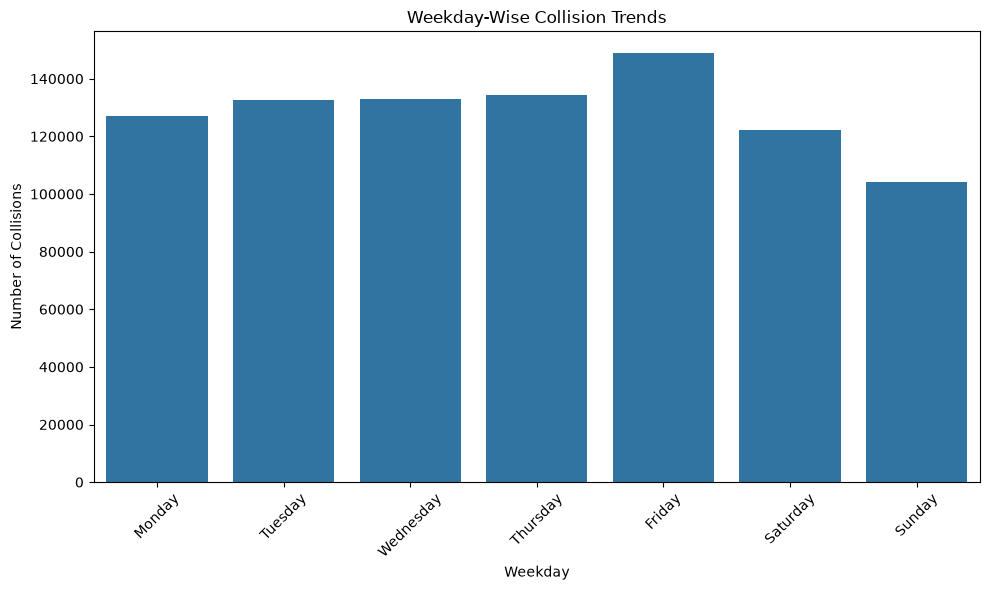

In [23]:

# Extract the weekday

from pyspark.sql.functions import to_date, date_format, count, when

weekday_df = (
    collisions
    .withColumn(
        "weekday",
        date_format(to_date("collision_date"), "EEEE")
    )
    .groupBy("weekday")
    .count()
)

# Arrange weekdays in correct order

weekday_df = (
    weekday_df
    .withColumn(
        "weekday_order",
        when(weekday_df["weekday"] == "Monday", 1)
        .when(weekday_df["weekday"] == "Tuesday", 2)
        .when(weekday_df["weekday"] == "Wednesday", 3)
        .when(weekday_df["weekday"] == "Thursday", 4)
        .when(weekday_df["weekday"] == "Friday", 5)
        .when(weekday_df["weekday"] == "Saturday", 6)
        .when(weekday_df["weekday"] == "Sunday", 7)
    )
    .orderBy("weekday_order")
)

weekday_df.show()

# Convert to Pandas

weekday_pd = weekday_df.toPandas()

# Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weekday_pd,
    x="weekday",
    y="count"
)

plt.title("Weekday-Wise Collision Trends")
plt.xlabel("Weekday")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

+---------------+------+
|caltrans_county| count|
+---------------+------+
|        Unknown|657236|
|    los angeles| 63235|
|         orange| 22790|
| san bernardino| 15943|
|      san diego| 15701|
|        alameda| 13788|
|      riverside| 12979|
|    santa clara| 11669|
|     sacramento|  7736|
|      san mateo|  6136|
|        ventura|  5541|
|   contra costa|  5430|
|           kern|  4973|
|    san joaquin|  4320|
|         fresno|  3792|
|  santa barbara|  3680|
|         solano|  3387|
|         sonoma|  3102|
|  san francisco|  3004|
|     stanislaus|  2995|
+---------------+------+
only showing top 20 rows



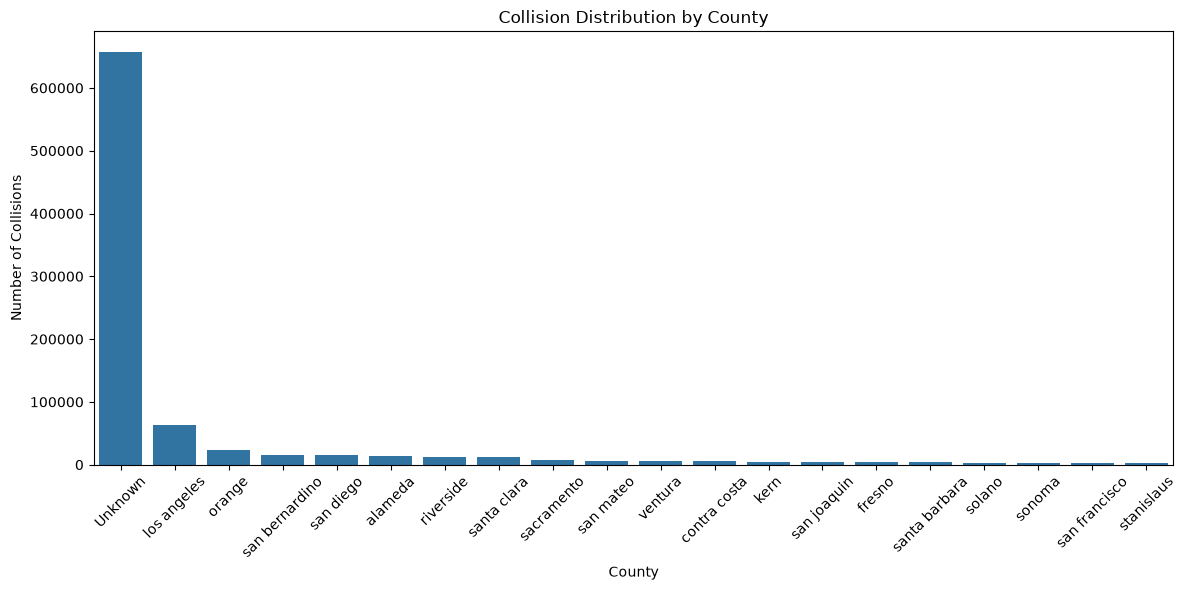

In [24]:
# Spatial Analysis

# Collision Density by County

county_df = (
    collisions
    .groupBy("caltrans_county")
    .count()
    .orderBy("count", ascending=False)
)

county_df.show()

# Convert to Pandas

county_pd = county_df.toPandas()

# Plot the map / county distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    data=county_pd.head(20),
    x="caltrans_county",
    y="count"
)

plt.title("Collision Distribution by County")
plt.xlabel("County")
plt.ylabel("Number of Collisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

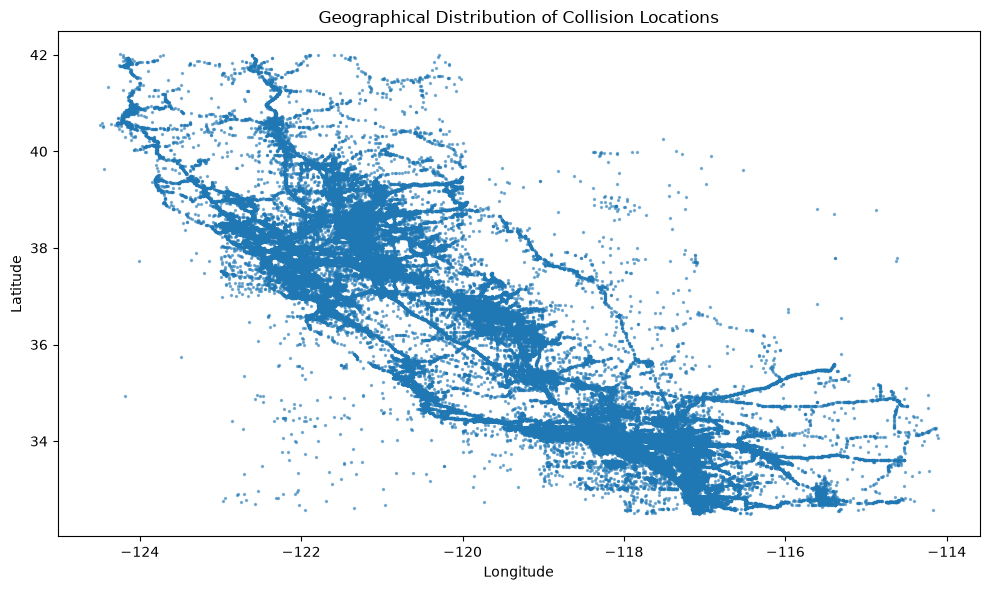

In [25]:
# Scatter Plot of Collision Locations

# Convert PySpark DataFrame to Pandas, handling potential missing values

location_pd = collisions.select(
    "longitude",
    "latitude"
).toPandas()

# Convert to numeric and handle invalid data

import pandas as pd

location_pd["longitude"] = pd.to_numeric(
    location_pd["longitude"],
    errors="coerce"
)

location_pd["latitude"] = pd.to_numeric(
    location_pd["latitude"],
    errors="coerce"
)

location_pd = location_pd.dropna(
    subset=["longitude", "latitude"]
)

# Plot the scatter plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    location_pd["longitude"],
    location_pd["latitude"],
    s=2,
    alpha=0.5
)

plt.title("Geographical Distribution of Collision Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()


##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [26]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col

# Extract year and month from collision_date

collisions = (
    collisions
    .withColumn("year", year(to_timestamp(col("collision_date"))))
    .withColumn("month", month(to_timestamp(col("collision_date"))))
    .withColumn(
        "hour",
        hour(to_timestamp(col("collision_time"), "HH:mm:ss"))
    )
)

collisions.select(
    "collision_date",
    "collision_time",
    "year",
    "month",
    "hour"
).show(10)


+--------------+-------------------+----+-----+----+
|collision_date|     collision_time|year|month|hour|
+--------------+-------------------+----+-----+----+
|    2013-01-24|2026-08-18 05:45:00|2013|    1|   5|
|    2013-08-06|2026-08-18 20:15:00|2013|    8|  20|
|    2014-07-12|2026-08-18 04:40:00|2014|    7|   4|
|    2014-07-01|2026-08-18 18:05:00|2014|    7|  18|
|    2015-03-08|2026-08-18 13:18:00|2015|    3|  13|
|    2008-09-12|2026-08-18 17:15:00|2008|    9|  17|
|    2011-06-26|2026-08-18 12:50:00|2011|    6|  12|
|    2010-08-12|2026-08-18 22:55:00|2010|    8|  22|
|    2009-04-22|2026-08-18 08:05:00|2009|    4|   8|
|    2018-06-27|2026-08-18 08:59:00|2018|    6|   8|
+--------------+-------------------+----+-----+----+
only showing top 10 rows



Q: Analyze yearly, monthly and hourly trends in collisions.

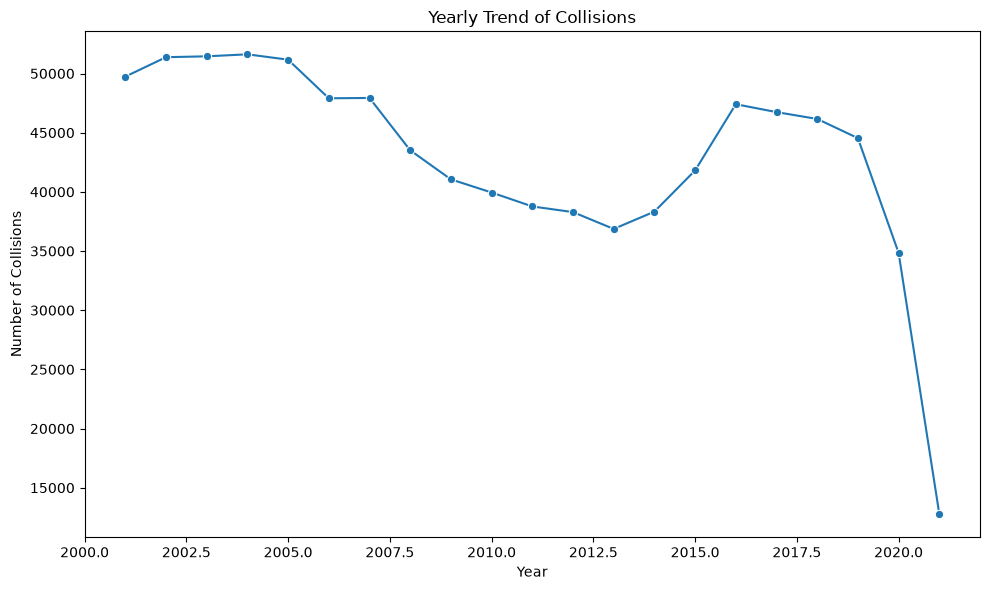

In [27]:
# Yearly Trend of Collisions

yearly_df = (
    collisions
    .groupBy("year")
    .count()
    .orderBy("year")
)

yearly_pd = yearly_df.toPandas()

# Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly_pd,
    x="year",
    y="count",
    marker="o"
)

plt.title("Yearly Trend of Collisions")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.tight_layout()
plt.show()


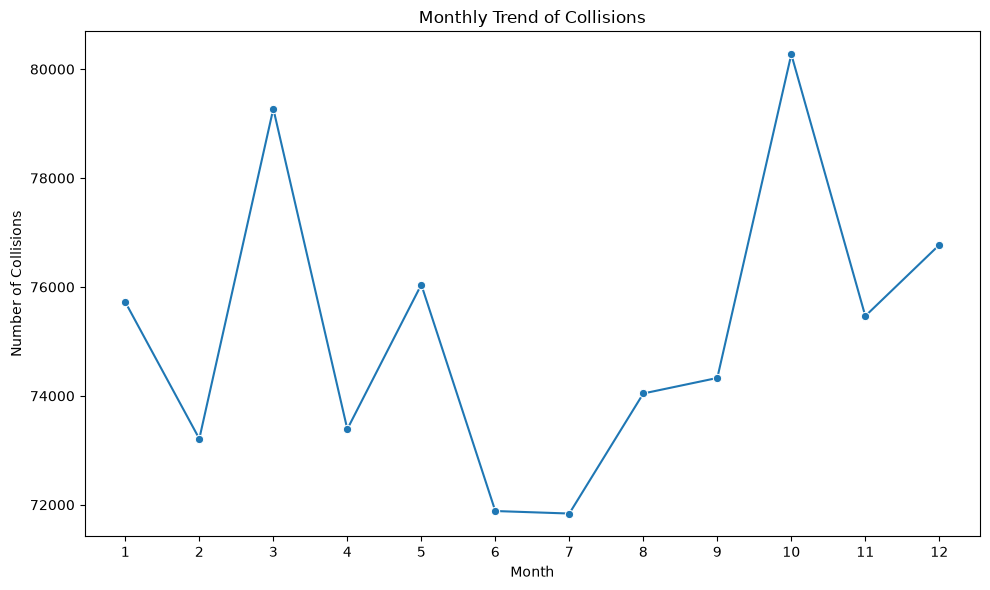

In [28]:
# Monthly Trend of Collisions

monthly_df = (
    collisions
    .groupBy("month")
    .count()
    .orderBy("month")
)

monthly_pd = monthly_df.toPandas()

# Plot

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_pd,
    x="month",
    y="count",
    marker="o"
)

plt.title("Monthly Trend of Collisions")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

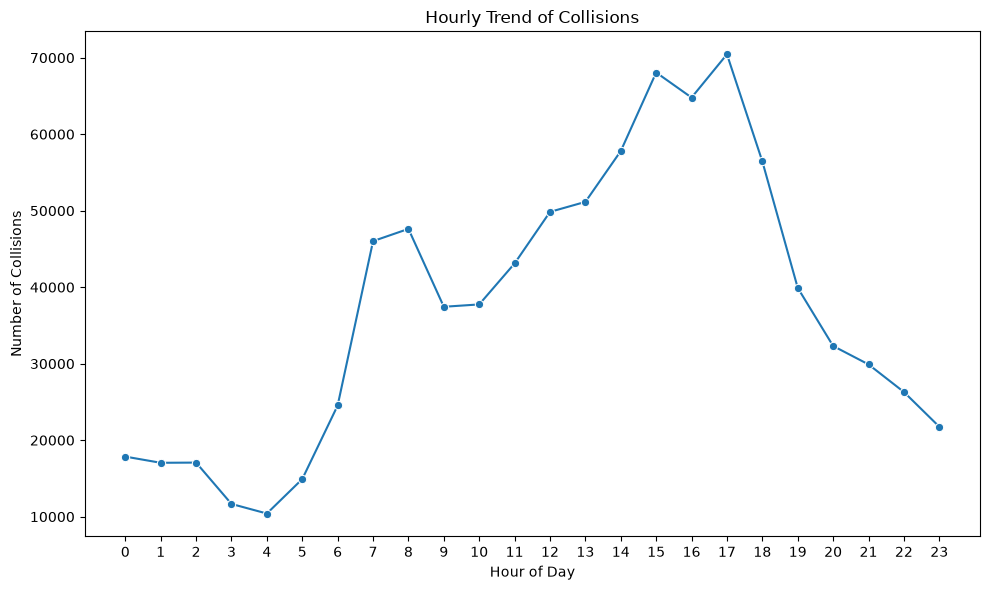

In [29]:
# Hourly Trend of Collisions

hourly_df = (
    collisions
    .groupBy("hour")
    .count()
    .orderBy("hour")
)

hourly_pd = hourly_df.toPandas()

# Plot

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=hourly_pd,
    x="hour",
    y="count",
    marker="o"
)

plt.title("Hourly Trend of Collisions")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [30]:
# Query: Identify the top 5 counties with the most collisions

# Query: Identify the top 5 counties with the most collisions

top_5_counties = (
    collisions
    .filter(col("caltrans_county").isNotNull())
    .groupBy("caltrans_county")
    .count()
    .orderBy(col("count").desc())
    .limit(5)
)

top_5_counties.show()

+---------------+------+
|caltrans_county| count|
+---------------+------+
|        Unknown|657236|
|    los angeles| 63235|
|         orange| 22790|
| san bernardino| 15943|
|      san diego| 15701|
+---------------+------+



## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [31]:
# Query: Find the month with the highest number of collisions

highest_collision_month = (
    collisions
    .groupBy("month")
    .count()
    .orderBy(col("count").desc())
    .limit(1)
)

highest_collision_month.show()


+-----+-----+
|month|count|
+-----+-----+
|   10|80273|
+-----+-----+



## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [32]:
# Query: Find the most common weather condition during collisions

most_common_weather = (
    collisions
    .groupBy("weather_1")
    .count()
    .orderBy(col("count").desc())
    .limit(1)
)

most_common_weather.show()


+---------+------+
|weather_1| count|
+---------+------+
|    clear|741919|
+---------+------+



## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [33]:
# Query: Determine the percentage of collisions that resulted in fatalities

total_collisions = collisions.count()

fatal_collisions = (
    collisions
    .filter(col("collision_severity") == "Fatal")
    .count()
)

fatal_percentage = (fatal_collisions / total_collisions) * 100

print("Percentage of collisions resulting in fatalities:", fatal_percentage)

collisions.select("collision_severity").distinct().show(truncate=False)


Percentage of collisions resulting in fatalities: 0.0
+--------------------+
|collision_severity  |
+--------------------+
|property damage only|
|pain                |
|other injury        |
|severe injury       |
+--------------------+



## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [34]:
# Query: Find the most dangerous time of day for collisions

from pyspark.sql.functions import col, count

dangerous_time_df = (
    collisions
    .groupBy("hour")
    .agg(count("*").alias("collision_count"))
    .orderBy(col("collision_count").desc())
)

dangerous_time_df.show(1)

+----+---------------+
|hour|collision_count|
+----+---------------+
|  17|          70448|
+----+---------------+
only showing top 1 row



## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [35]:
# Query: List the top 5 road types with the highest collision frequency

# Query: Top 5 road surface conditions with highest collision frequency

road_surface_df = (
    collisions
    .groupBy("road_surface")
    .count()
    .orderBy("count", ascending=False)
    .limit(5)
)

road_surface_df.show()

+------------+------+
|road_surface| count|
+------------+------+
|         dry|814906|
|         wet| 74481|
|     Unknown|  7848|
|       snowy|  3991|
|    slippery|  1013|
+------------+------+



## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [36]:
# Query: Find the top 3 lighting conditions that lead to the most collisions

lighting_df = (
    collisions
    .groupBy("lighting")
    .count()
    .orderBy("count", ascending=False)
    .limit(3)
)

lighting_df.show()


+--------------------+------+
|            lighting| count|
+--------------------+------+
|            daylight|602889|
|dark with street ...|188735|
|dark with no stre...| 72223|
+--------------------+------+



##5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

# Final Insights and Recommendations

## Conclusion

The analysis of collision data shows several important patterns and trends.

1. **Yearly Trend:** The number of collisions changed significantly over the years, with higher collision counts in the earlier years and a noticeable decline in the later years.

2. **Monthly Trend:** Collisions varied across different months, showing that collision frequency is not uniform throughout the year.

3. **Hourly Trend:** The most dangerous time of day was **5 PM (17:00)**, with approximately **70,448 collisions**. This indicates that the evening period has a particularly high collision frequency.

4. **Road Surface Conditions:** The top road surface conditions associated with collisions were:
   - Dry: **814,906**
   - Wet: **74,481**
   - Unknown: **7,848**
   - Snowy: **3,991**
   - Slippery: **1,013**

   Dry and wet road surfaces had the highest collision frequencies.

5. **Lighting Conditions:** The highest number of collisions occurred during:
   - Daylight: **602,889**
   - Dark with street lights: **188,735**
   - Dark with no street lights: **72,223**

### Recommendations

- Road safety measures should be strengthened during the evening peak hours.
- Drivers should be more cautious during wet and slippery road conditions.
- Proper street lighting should be maintained in areas with frequent nighttime collisions.
- Traffic monitoring and awareness campaigns should focus on high-risk periods and locations.
- The identified collision patterns can help authorities plan better road-safety strategies and reduce accidents.

#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>